# Krzywe uczenia (learning curve)

**Krzywa uczenia (ang. *learning curve*)** to narzędzie służące do oceny, jak zmienia się wydajność modelu uczenia maszynowego w zależności od liczby przykładów uczących. Pozwala na:

* wykrycie **niedouczenia** (underfittingu), gdy model osiąga niską dokładność nawet na zbiorze treningowym,
* wykrycie **przeuczenia** (overfittingu), gdy model ma wysoką dokładność na treningu, ale słabą na walidacji,
* ocenę, czy **zwiększenie liczby danych** przyniosłoby poprawę.

W scikit-learn funkcja `learning_curve` oblicza metryki dla rosnących rozmiarów zbioru treningowego. Do wizualizacji wyników służy `LearningCurveDisplay.from_estimator`.

---

Krzywe uczenia mogą być stosowane zarówno w klasyfikacji, jak i w regresji. Pokazują, jak zmienia się jakość modelu na zbiorze treningowym i walidacyjnym wraz ze wzrostem liczby danych treningowych.

W klasyfikacji krzywe uczenia można tworzyć dla metryk takich jak accuracy, precision, recall, f1 czy roc_auc. Pomagają ocenić, czy model poprawia zdolność rozpoznawania klas wraz z większą liczbą danych.

W regresji krzywe uczenia można tworzyć dla metryk takich jak r2, neg_mean_squared_error, neg_mean_absolute_error czy neg_root_mean_squared_error. Pomagają sprawdzić, czy model coraz lepiej przewiduje wartości ciągłe wraz ze wzrostem liczby przykładów.

---

Wykres:

* **Krzywa treningowa**: jak model uczy się na coraz większym zbiorze danych.
* **Krzywa walidacyjna**: jak rośnie jego ogólna zdolność do generalizacji.
* **Rozrzut** (pasy cieniowania): informacja o stabilności wyniku.

---

Parametry do optymalizacji: https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

---

**Opis zbioru `digits` (scikit-learn)**

Zbiór `digits` to klasyczny, niewielki zbiór danych do klasyfikacji obrazów cyfr. Zawiera:

* **1797 próbek** obrazów cyfr (`0`–`9`)
* Każdy obraz to **8×8 pikseli** (czyli 64 cechy), wartości pikseli od `0` do `16`
* Celem jest **rozpoznanie cyfr** zapisanych odręcznie (klasyfikacja wieloklasowa)
Wymiary:

    * `X.shape = (1797, 64)`
    * `y.shape = (1797,)` (etykiety klas od 0 do 9)

---

In [31]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

from sklearn.model_selection import learning_curve
from sklearn.model_selection import LearningCurveDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [32]:
# Dane
X, y = load_digits(return_X_y=True)
cv = StratifiedKFold(n_splits=5)
train_sizes = np.linspace(0.1, 1.0, 10)

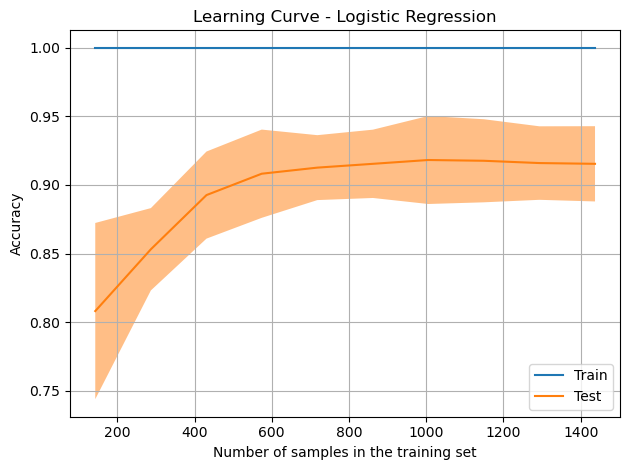

In [33]:
# Model: regresja logistyczna
model = LogisticRegression(max_iter=1000, solver='lbfgs')

# Krzywa uczenia
cv = StratifiedKFold(n_splits=5)
train_sizes = np.linspace(0.1, 1.0, 10)

# Rysowanie krzywej
LearningCurveDisplay.from_estimator(
    estimator=model,
    X=X,
    y=y,
    train_sizes=train_sizes,
    cv=cv,
    scoring='accuracy', # f1, precision, recall, ale trzeba wskazać właściwą klasę, można też np.: "precision_weighted"
    n_jobs=-1
)

plt.title("Learning Curve - Logistic Regression")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretacja**:
  
* **Model**: Regresja logistyczna (`LogisticRegression`)
* **Dane**: Zbiór `digits` — rozpoznawanie cyfr (klasyfikacja wieloklasowa)
* **Metryka**: Dokładność klasyfikacji (`accuracy`)
* **Walidacja**: 5-krotna walidacja krzyżowa (`StratifiedKFold`)
* **Zakres danych uczących**: Od 10% do 100% zbioru

---

1. **Krzywa treningowa**:

   * Startuje wysoko (np. >0.99) przy małej liczbie próbek — model łatwo „zapamiętuje” dane.

2. **Krzywa walidacyjna**:

   * Zaczyna niżej (np. ok. 0.80) przy małej liczbie danych, ponieważ model generalizuje słabo przy ograniczonym treningu.
   * **Stopniowo rośnie**, pokazując, że model uczy się lepiej wraz ze wzrostem liczby przykładów uczących.
   * W końcu **osiąga plateau** — dalsze zwiększanie zbioru treningowego nie poprawia znacząco wyników.

---

**Wnioski**:

* **Brak silnego overfittingu**: odległość między krzywą treningową a walidacyjną nie jest drastyczna.
* **Model dobrze generalizuje**: walidacja osiąga wysoki poziom (np. >0.9), z niewielkim rozrzutem.
* **Zwiększanie danych może dać niewielką poprawę**, ale korzyści maleją — osiągnięto prawdopodobnie punkt nasycenia modelu.

---

Porównajmy różne modele:

In [34]:
# Modele
models = {
    'Regresja logistyczna': LogisticRegression(max_iter=1000, solver='lbfgs'),
    'Drzewo decyzyjne': DecisionTreeClassifier(random_state=42),  # brak ograniczeń -> może być przeuczenie
    'Drzewo decyzyjne (głębokość = 1)': DecisionTreeClassifier(max_depth=1, random_state=42),  # bardzo prosty model, niedouczenie
    'Gaussian Naive Bayes': GaussianNB() # niedopasowanie założeń - niezależność cech
}

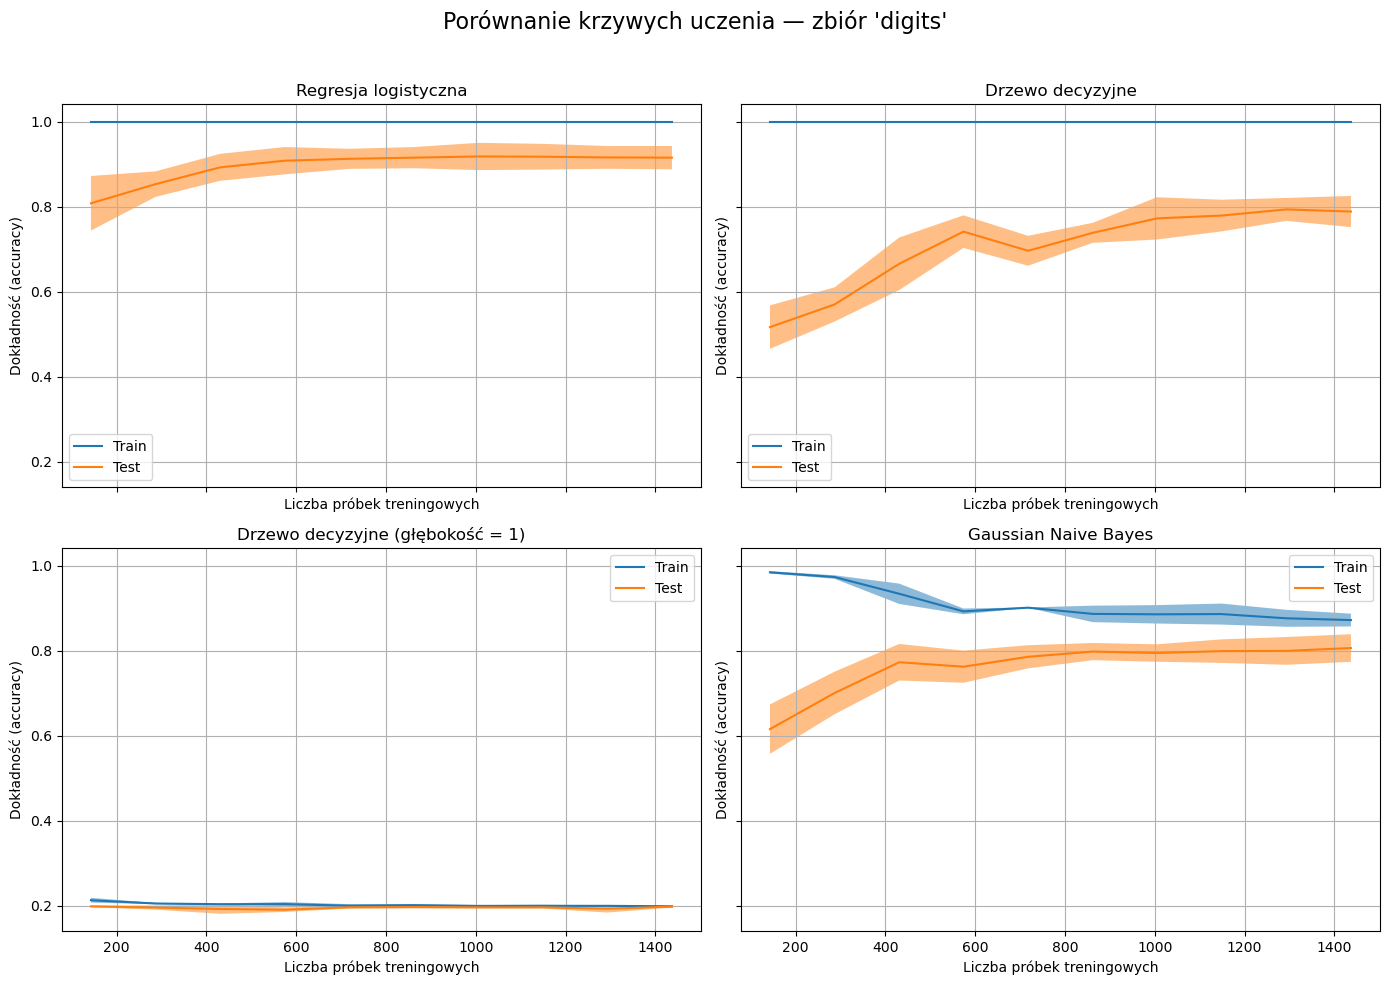

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

# Rysowanie każdego modelu
for ax, (name, model) in zip(axes.ravel(), models.items()):
    LearningCurveDisplay.from_estimator(
        estimator=model,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Liczba próbek treningowych")
    ax.set_ylabel("Dokładność (accuracy)")
    ax.grid(True)

plt.suptitle("Porównanie krzywych uczenia — zbiór 'digits'", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

lub z wykorzystaniem: `learning_curv`:

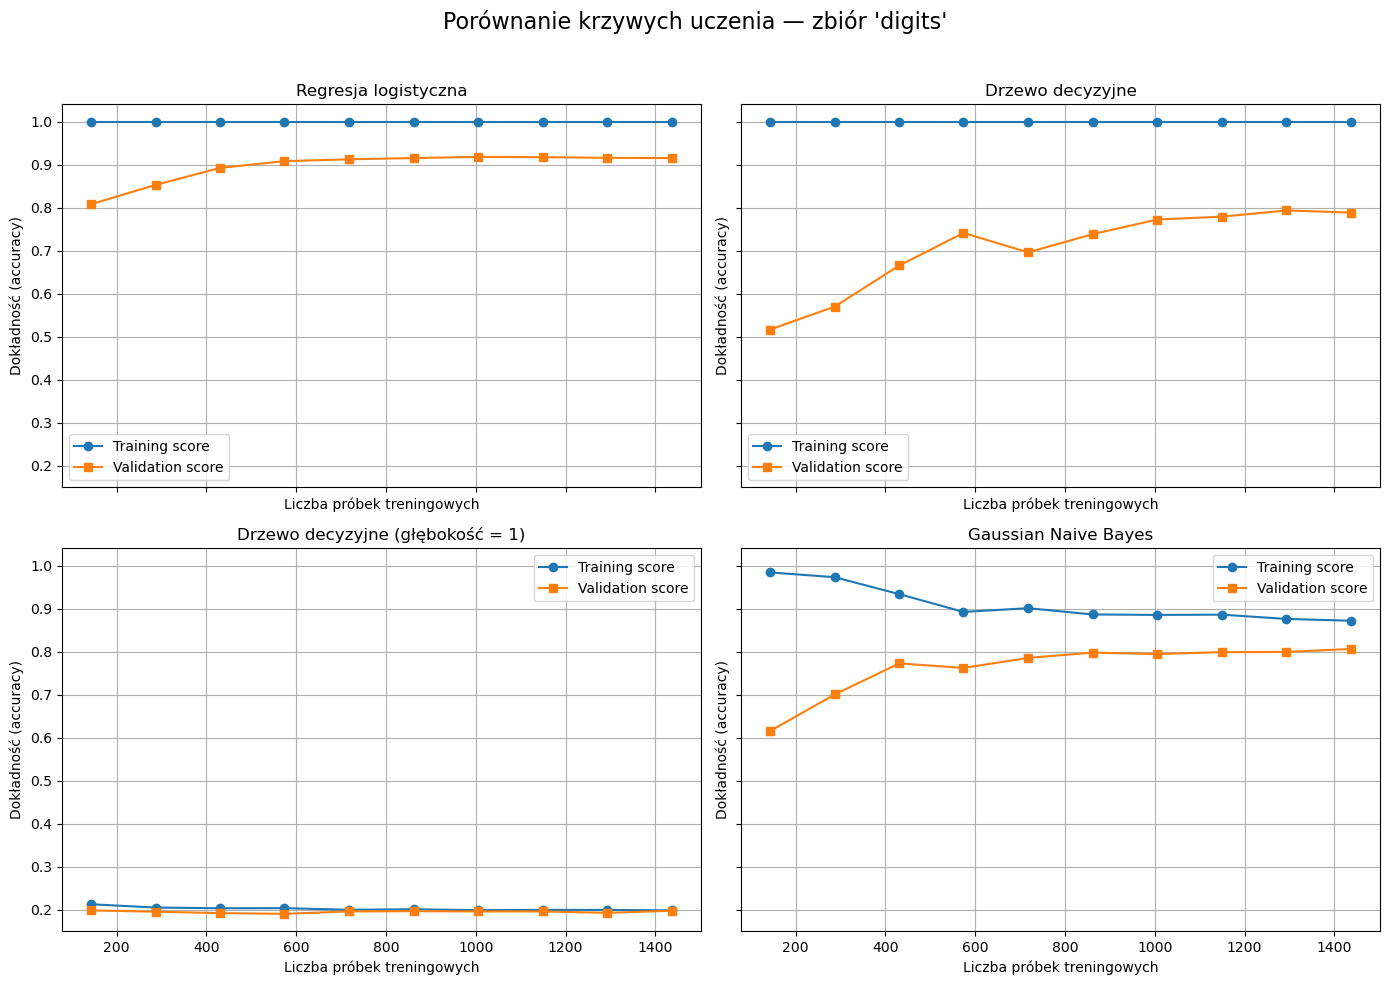

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

# Rysowanie każdego modelu
for ax, (name, model) in zip(axes.ravel(), models.items()):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    ax.plot(train_sizes_abs, train_mean, label='Training score', marker='o')
    ax.plot(train_sizes_abs, val_mean, label='Validation score', marker='s')

    ax.set_title(name)
    ax.grid(True)
    ax.set_xlabel("Liczba próbek treningowych")
    ax.set_ylabel("Dokładność (accuracy)")
    ax.legend()

plt.suptitle("Porównanie krzywych uczenia — zbiór 'digits'", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Interpretacja**:

* **Regresja logistyczna**: dobre dopasowanie, niewielka luka, dobra generalizacja.
* **Drzewo decyzyjne (bez ograniczeń)**: silny overfitting — prawie 100% na treningu, ale niższy wynik walidacyjny.
* **Drzewo głębokości 1**: underfitting — niska dokładność nawet na zbiorze treningowym.
* **GaussianNB**: umiarkowana skuteczność, stabilna, ale niższa dokładność z powodu niedopasowania do danych.

Oto szczegółowe wyjaśnienie interpretacji wyników krzywych uczenia dla każdego z czterech modeli:

---

**1. Regresja logistyczna**

**Dobre dopasowanie, niewielka luka, dobra generalizacja.**

* **Krzywa treningowa i walidacyjna są blisko siebie**, co oznacza, że model nie przeucza się (brak dużej różnicy między wynikami na treningu a walidacji).
* **Obie krzywe osiągają wysoką dokładność (\~0.9 i więcej)**, co świadczy o tym, że model dobrze odwzorowuje zależności w danych.
* **Stabilny przebieg krzywej walidacyjnej** sugeruje, że model dobrze radzi sobie z generalizacją – potrafi trafnie klasyfikować dane, których wcześniej nie widział.

**Wniosek:** regresja logistyczna to prosty, ale skuteczny model liniowy, który działa dobrze, gdy dane mają strukturę nadającą się do separacji liniowej (jak w zbiorze `digits` po redukcji wymiarów).

---

**2. Drzewo decyzyjne (bez ograniczeń głębokości)**

**Silny overfitting — prawie 100% na treningu, ale niższy wynik walidacyjny.**

* **Trening accuracy ≈ 100%** — drzewo perfekcyjnie zapamiętuje dane treningowe (nawet szum).
* **Validation accuracy jest znacznie niższa i niestabilna** — model nie generalizuje dobrze, bo dostosował się zbyt dokładnie do konkretnych danych uczących.
* **Szeroka luka między krzywymi** wskazuje na przeuczenie (**overfitting**).

**Wniosek:** drzewo bez ograniczeń głębokości jest zbyt złożone. Dobrze "zapamiętuje" dane treningowe, ale nie uczy się ogólnych wzorców.

---

**3. Drzewo decyzyjne z maksymalną głębokością = 1**

**Underfitting — niska dokładność nawet na zbiorze treningowym.**

* **Trening accuracy jest niska (\~0.6–0.7)** — model jest zbyt prosty, by uchwycić nawet wzorce obecne w danych uczących.
* **Validation accuracy również niska i podobna do treningowej** — nie występuje overfitting, ale model też nie ma wystarczającej mocy predykcyjnej.
* **Brak poprawy wraz ze wzrostem danych** — model jest zbyt ograniczony.

**Wniosek:** zbyt mała głębokość drzewa powoduje **niedouczenie** (**underfitting**), nawet jeśli dostarczymy mu dużo danych.

---

**4. Gaussian Naive Bayes**

**Umiarkowana skuteczność, stabilna, ale niższa dokładność z powodu niedopasowania do danych.**

* **Training accuracy umiarkowana (\~0.8), ale nie rośnie znacząco z liczbą danych** — model bazuje na uproszczonym założeniu niezależności cech.
* **Validation accuracy jest niższa, ale stabilna** — świadczy to o tym, że model generalizuje w sposób przewidywalny, ale ograniczony.
* **Brak dużej luki między krzywymi** nie oznacza, że model działa dobrze — tylko że **błędy wynikają z uproszczenia modelu**, a nie z nadmiernego dopasowania.

**Wniosek:** `GaussianNB` ma ograniczoną reprezentatywność dla złożonych zbiorów, takich jak obrazy cyfr, gdzie cechy są skorelowane (np. sąsiednie piksele).

---

# Krzywa walidacyjne (Validation Curve)

**Validation curve** (krzywa walidacyjna) pokazuje, jak zmienia się wydajność modelu w zależności od wartości **jednego z jego hiperparametrów**.

Pozwala odpowiedzieć na pytania:

* Czy model jest **zbyt prosty** (underfitting) lub **zbyt złożony** (overfitting)?
* Jak dobrać **optymalną wartość hiperparametru** (np. głębokość drzewa, C, gamma)?

---

W scikit-learn można wygenerować dane krzywej walidacyjnej funkcją `validation_curve()`, a zwizualizować je za pomocą `ValidationCurveDisplay.from_estimator()`.

---

Poniżej przykłady Validation Curve — różne modele, różne hiperparametry:

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import ValidationCurveDisplay

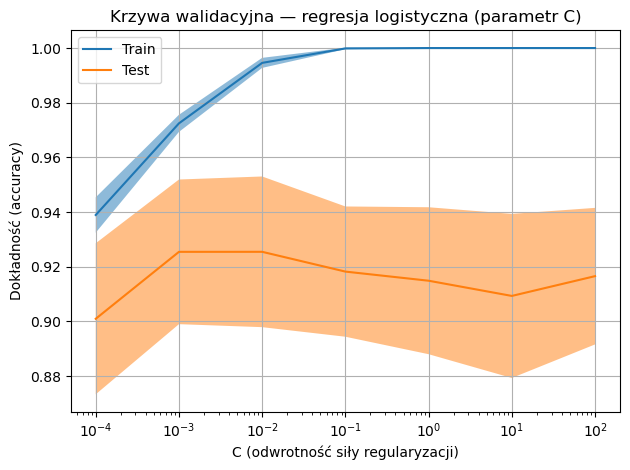

In [38]:
# Dane
X, y = load_digits(return_X_y=True)

# Model i parametry
model = LogisticRegression(max_iter=1000)
param_name = "C"
param_range = np.logspace(-4, 2, 7)  # np. [0.0001, ..., 100]

# Walidacja krzyżowa
cv = StratifiedKFold(n_splits=5)

# Wykres
ValidationCurveDisplay.from_estimator(
    estimator=model,
    X=X,
    y=y,
    param_name=param_name,
    param_range=param_range,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

plt.title("Krzywa walidacyjna — regresja logistyczna (parametr C)")
plt.xlabel("C (odwrotność siły regularyzacji)")
plt.ylabel("Dokładność (accuracy)")
plt.xscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

I porównanie kilku modeli i hiperparametrów:

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import ValidationCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

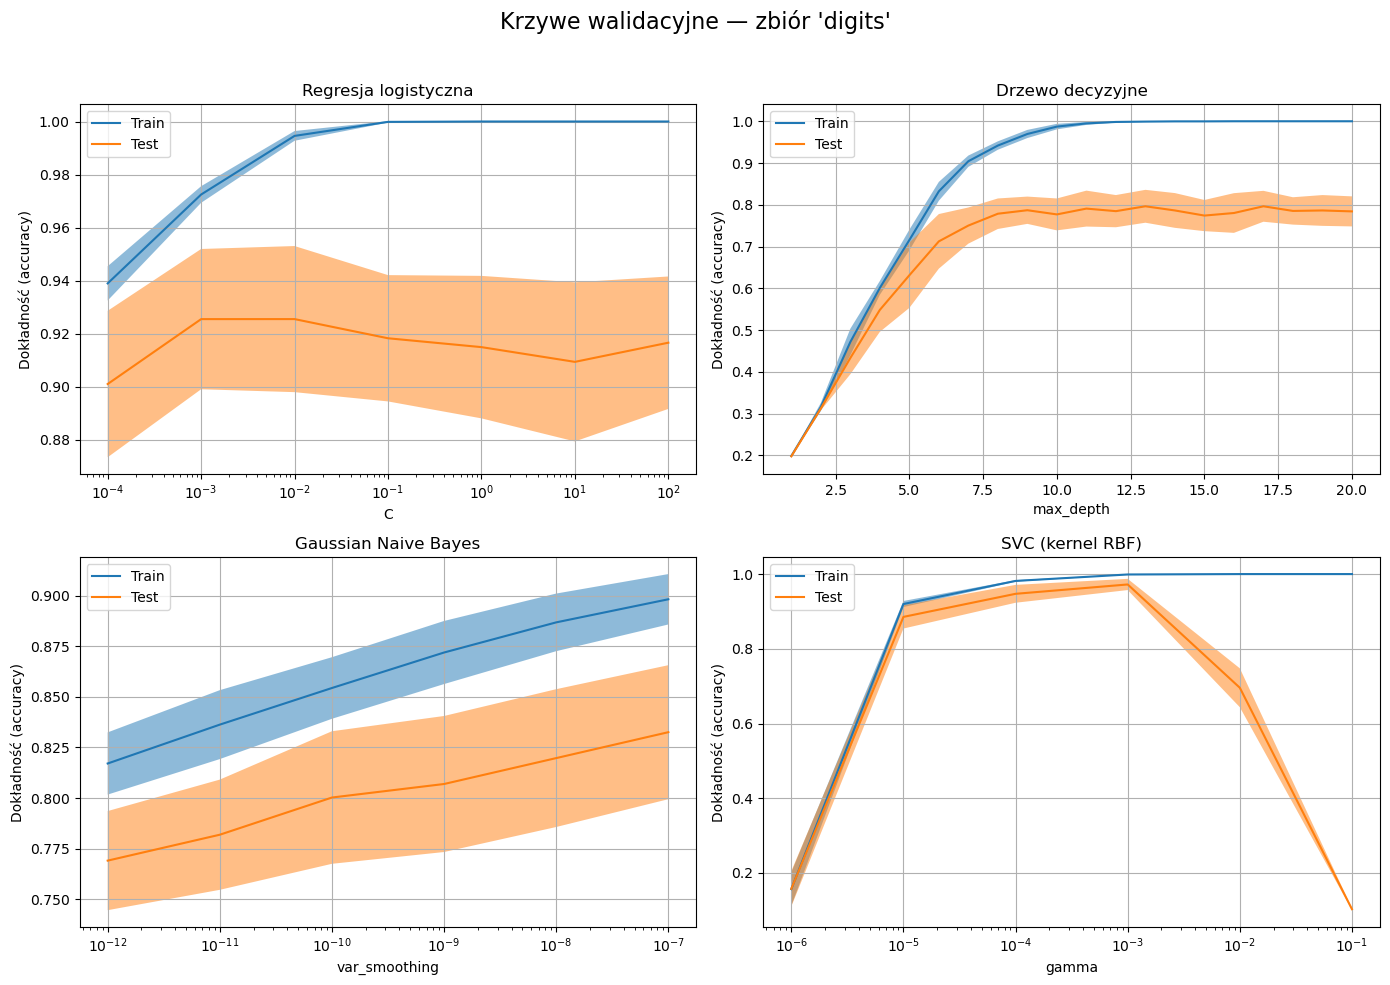

In [40]:
# Dane i konfiguracja
X, y = load_digits(return_X_y=True)
cv = StratifiedKFold(n_splits=5)

# Parametry i modele
models_params = [
    (
        "Regresja logistyczna",
        LogisticRegression(max_iter=1000),
        "C",
        np.logspace(-4, 2, 7)
    ),
    (
        "Drzewo decyzyjne",
        DecisionTreeClassifier(),
        "max_depth",
        np.arange(1, 21)
    ),
    (
        "Gaussian Naive Bayes",
        GaussianNB(),
        "var_smoothing",
        np.logspace(-12, -7, 6)
    ),
    (
        "SVC (kernel RBF)",
        SVC(),
        "gamma",
        np.logspace(-6, -1, 6)
    )
]

# Tworzenie subplotów
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rysowanie krzywych walidacyjnych
for ax, (title, model, param_name, param_range) in zip(axes.ravel(), models_params):
    ValidationCurveDisplay.from_estimator(
        estimator=model,
        X=X,
        y=y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(param_name)
    ax.set_ylabel("Dokładność (accuracy)")
    ax.grid(True)

plt.suptitle("Krzywe walidacyjne — zbiór 'digits'", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Interpretacja (validation curve)**

1. **Regresja logistyczna – parametr `C`**:

* `C` steruje **siłą regularyzacji** — mniejsze `C` oznacza silniejszą regularyzację.
* Przy bardzo małym `C` model jest zbyt prosty (**underfitting**): niska skuteczność zarówno na treningu, jak i walidacji.
* Przy bardzo dużym `C` model zaczyna się przeuczać (**overfitting**): wysoka dokładność treningowa, spadająca walidacyjna.
* **Optimum** występuje przy średnim `C`, np. `C ≈ 1–10`.

2. **DecisionTreeClassifier – parametr `max_depth`**:

* Niskie `max_depth` → zbyt proste drzewo, słabe wyniki na obu zbiorach.
* Wzrost `max_depth` poprawia wynik, aż do momentu, gdy **model uczy się na pamięć**.
* Od pewnej głębokości krzywa walidacyjna **spada**, a treningowa zostaje wysoka – sygnał **overfittingu**.
* **Optimum** to kompromisowa głębokość, np. `max_depth ≈ 5–10`.

3. **GaussianNB – parametr `var_smoothing`**:

* Zbyt małe `var_smoothing` → niestabilność obliczeń (dzielenie przez bliskie zera), pogorszenie wyniku.
* Zbyt duże → nadmierne wygładzanie wariancji, utrata informacji, niska skuteczność.
* **Optimum** zwykle w środku, np. `1e-9` – daje najlepsze wyniki walidacyjne.

4. **SVC (kernel RBF) – parametr `gamma`**:

* `gamma` określa promień działania pojedynczego punktu:

  * **zbyt małe** → zbyt gładka granica → **underfitting**,
  * **zbyt duże** → granica zbyt szczegółowa → **overfitting**.
* Krzywa walidacyjna osiąga maksimum przy **średnim gamma**, a potem gwałtownie spada.
* **Optimum**: zwykle w środku, np. `gamma ≈ 1e-3`.

---

## Stabilność modelu

**Zacieniowane pole wokół krzywych na wykresie krzywej uczenia lub walidacyjnej** reprezentuje **rozrzut wyników (wariancję)** pomiędzy różnymi podziałami danych w ramach walidacji krzyżowej.

---

* Jest to **odchylenie standardowe** wyników (np. dokładności) dla danego rozmiaru zbioru treningowego lub danej wartości hiperparametru.
* Pokazuje, **jak bardzo zmienia się wynik w zależności od tego, które dane zostały użyte do treningu i walidacji**.
* Obliczane osobno dla:

  * krzywej treningowej (np. `± std(train_scores)`),
  * krzywej walidacyjnej (np. `± std(val_scores)`).

---

**Interpretacja szerokości cienia**:
* **Wąska (mała wariancja)** - Model daje **spójne wyniki** — jest **stabilny** między foldami. 
* **Szeroka (duża wariancja)** - Model ma **niestabilne wyniki** — może silnie zależeć od danych. 

Zatem **zacieniowanie mówi nie tylko o średnim wyniku, ale także o jego wiarygodności**.

---